# Data Analysis

Log

- 19/01/2025: Init

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Helpers

In [7]:
def extract_nr_of_sd_attributes(x: str) -> int:
    mi = re.match('.*-sd-(\d{3})-att', x)
    if mi is None or len(mi.groups()) < 1:
        raise Exception(f'Could not extract the number of selectively disclosed attributes from the given input string: {x}')
    return int(mi.group(1))

## Data

In [8]:
# default
fpath_records = './data/records.json'
# records-202501290231.json
# fpath_records = './data/records-202501290231.json'
def get_df() -> pd.DataFrame:
    return pd.read_json(fpath_records)

In [9]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

df.shape:  (3600, 8)
df ∑nRecords:  25200
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,vc01-sd-002-att,3,2,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,vc01-sd-002-att,3,2,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
3597,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,Iso18013DriversLicenseCredential-sd-016-att,21,16,149
3598,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,Iso18013DriversLicenseCredential-sd-016-att,21,16,149
3599,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,Iso18013DriversLicenseCredential-sd-016-att,21,16,149


a.shape:  (25200, 8)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,vc01-sd-002-att,3,2,0


b.shape:  (25200, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,684.176292,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,811.492500,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,811.972625,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [10]:
c = a[['iteration','implementationClass', 'credentialSetupKey']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (25200, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_SIGN_VC,mark,684.176292
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,END_SIGN_VC,mark,811.492500
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_VERIFY_VC,mark,811.972625


Filter: only keep `mark` entries.

In [11]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (25200, 6)


,iteration,implementationClass,credentialSetupKey,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_SIGN_VC,mark,684.176292
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,END_SIGN_VC,mark,811.492500
0,0,Implementation_BbsBlsSignature2020,vc01-sd-002-att,START_VERIFY_VC,mark,811.972625


Some final preprocessing.

In [12]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (25200, 6)


,iteration,credentialSetupKey,startTime,implementation,step,stepType
0,0,vc01-sd-002-att,684.176292,BbsBlsSignature2020,SIGN_VC,START
0,0,vc01-sd-002-att,811.492500,BbsBlsSignature2020,SIGN_VC,END
0,0,vc01-sd-002-att,811.972625,BbsBlsSignature2020,VERIFY_VC,START


## Analysis

In [13]:
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Return a copy of the last dataframe result from the previous section
    return e.copy()

**Background** 

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [14]:
dfa = get_dfa()
dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

dfa.shape:  (25200, 1)


startTime
implementation      credentialSetupKey iteration step      stepType            
BbsBlsSignature2020 vc01-sd-002-att    0         SIGN_VC   START     684.176292
                                                           END       811.492500
                                                 VERIFY_VC START     811.972625

In [31]:
# Make sure that every experiment has the same nr of records
assert dfa\
    .reset_index().groupby(['credentialSetupKey', 'implementation', 'step','stepType', 'iteration'],as_index=False ).first()\
    .groupby(['credentialSetupKey', 'implementation', 'step', 'stepType']).size()\
    .unique().__len__() == 1

In [32]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')
print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

df_delta.shape:  (12600, 1)


delta
implementation      credentialSetupKey                          iteration step                      
BbsBlsSignature2020 Iso18013DriversLicenseCredential-sd-002-att 0         DERIVE          141.287375
                                                                          SIGN_VC          28.800000
                                                                          VERIFY_DERIVED   45.159667

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [33]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          108.621378   
                                                                 SIGN_VC          27.881461   
                                                                 VERIFY_DERIVED   44.796113   
                                                                 VERIFY_VC        54.607156   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          106.741357   
...                                                                                     ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC         2.925465   
                     vc01-sd-002-att                             SIGN_VC          15.162432   
                                                                 VERIFY_VC        15.086143   
                     vc02-sd-002-att                             SIGN_VC          14.280497   
                                                                 VERIFY_VC        13.533275   

                                                                                      std  \
implementation       credentialSetupKey                          step                       
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          6.084158   
                                                                 SIGN_VC         0.336936   
                                                                 VERIFY_DERIVED  0.965014   
                                                                 VERIFY_VC       0.596454   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE          2.080925   
...                                                                                   ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC       0.243909   
                     vc01-sd-002-att                             SIGN_VC         1.302344   
                                                                 VERIFY_VC       1.555077   
                     vc02-sd-002-att                             SIGN_VC         1.009643   
                                                                 VERIFY_VC       0.426105   

                                                                                       var  \
implementation       credentialSetupKey                          step                        
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          37.016983   
                                                                 SIGN_VC          0.113526   
                                                                 VERIFY_DERIVED   0.931253   
                                                                 VERIFY_VC        0.355757   
                     Iso18013DriversLicenseCredential-sd-004-att DERIVE           4.330248   
...                                                                                    ...   
Ed25519Signature2020 Iso18013DriversLicenseCredential-sd-016-att VERIFY_VC        0.059492   
                     vc01-sd-002-att                             SIGN_VC          1.696100   
                                                                 VERIFY_VC        2.418265   
                     vc02-sd-002-att                             SIGN_VC          1.019380   
                                                                 VERIFY_VC        0.181566   

                                                                                        min  \
implementation       credentialSetupKey                          step                         
BbsBlsSignature2020  Iso18013DriversLicenseCredential-sd-002-att DERIVE          105.472542   
                                                                 SIGN_VC          27.141292   
                                      

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [34]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['implementation','credentialSetupKey',],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

implementation                             BbsBlsSignature2020  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  27.88   
VERIFY_VC                                                54.61   
DERIVE                                                  108.62   
VERIFY_DERIVED                                           44.80   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  27.51   
VERIFY_VC                                                54.03   
DERIVE                                                  106.74   
VERIFY_DERIVED                                           44.76   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  27.72   
VERIFY_VC                                                54.98   
DERIVE                                                  107.78   
VERIFY_DERIVED                                           46.51   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att   
step                                                             
SIGN_VC                                                  27.99   
VERIFY_VC                                                54.83   
DERIVE                                                  105.66   
VERIFY_DERIVED                                           45.82   

implementation                                      \
credentialSetupKey vc01-sd-002-att vc02-sd-002-att   
step                                                 
SIGN_VC                      72.10           69.04   
VERIFY_VC                    42.43           48.39   
DERIVE                      151.78          209.35   
VERIFY_DERIVED               43.54           44.56   

implementation                        BbsTermwiseSignature2023  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-002-att   
step                                                             
SIGN_VC                                                  93.66   
VERIFY_VC                                               105.41   
DERIVE                                                  234.37   
VERIFY_DERIVED                                          124.84   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-004-att   
step                                                             
SIGN_VC                                                  92.35   
VERIFY_VC                                               103.35   
DERIVE                                                  231.93   
VERIFY_DERIVED                                          125.84   

implementation                                                  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-008-att   
step                                                             
SIGN_VC                                                  94.38   
VERIFY_VC                                               105.87   
DERIVE                                                  232.82   
VERIFY_DERIVED                                          126.69   

implementation                                                  ...  \
credentialSetupKey Iso18013DriversLicenseCredential-sd-016-att  ...   
step                                                            ...   
SIGN_VC                                                  94.03  ...   
VERIFY_VC                                               105.20  ...   
DERIVE                   

Plotting (Seaborn)

In [35]:
dfsb = df_delta.reset_index()
dfsb['n_sd_att'] = dfsb.credentialSetupKey.apply(extract_nr_of_sd_attributes)
dfsb['credential'] = dfsb.credentialSetupKey.str.split('-sd').apply(lambda x: x[0])

print('dfsb.shape: ', dfsb.shape)
dfsb.head(3)

dfsb.shape:  (12600, 7)


,implementation,credentialSetupKey,iteration,step,delta,n_sd_att,credential
0,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,DERIVE,141.287375,2,Iso18013DriversLicenseCredential
1,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,SIGN_VC,28.800000,2,Iso18013DriversLicenseCredential
2,BbsBlsSignature2020,Iso18013DriversLicenseCredential-sd-002-att,0,VERIFY_DERIVED,45.159667,2,Iso18013DriversLicenseCredential


In [38]:
evaluated_credentials = list(dfsb.credential.unique())
evaluated_credentials

['Iso18013DriversLicenseCredential', 'vc01', 'vc02']

## All credentials

In [57]:
implementation_order = sorted(dfsb.implementation.unique())
print(implementation_order)

['BbsBlsSignature2020', 'BbsTermwiseSignature2023', 'EcdsaSd2023Cryptosuite', 'Ed25519Signature2020']


In [58]:
# Compute value counts for credentialSetupKey
csk_vc = dfsb['credentialSetupKey'].value_counts(dropna=False)

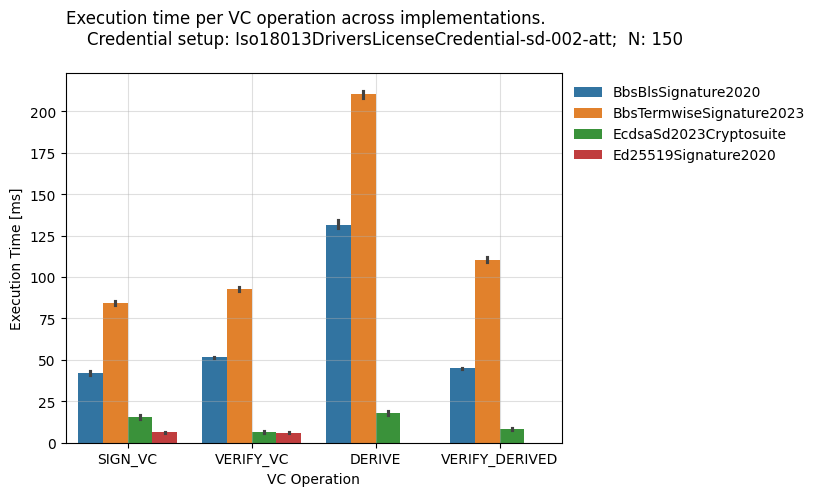

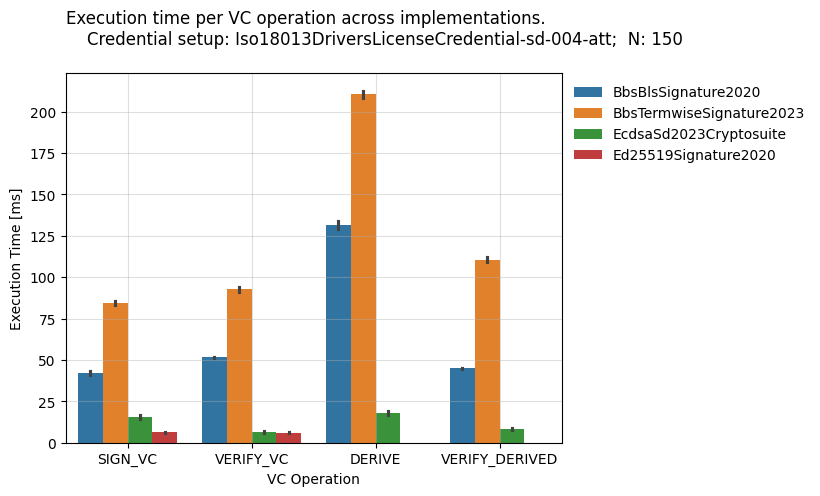

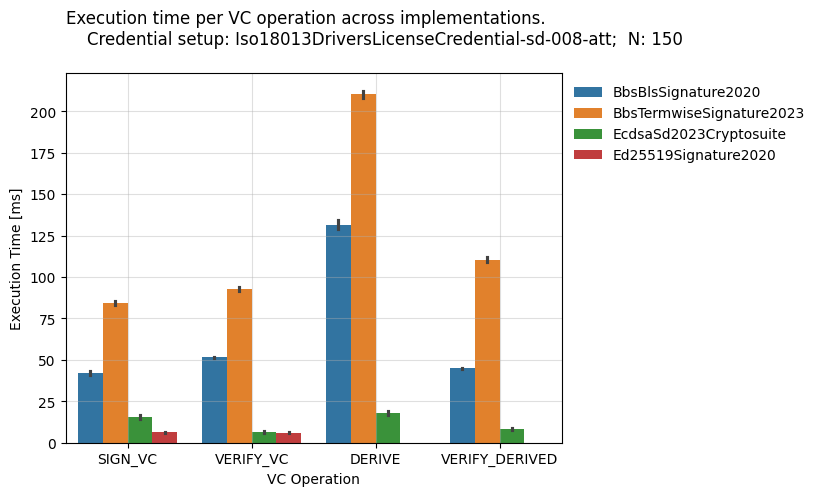

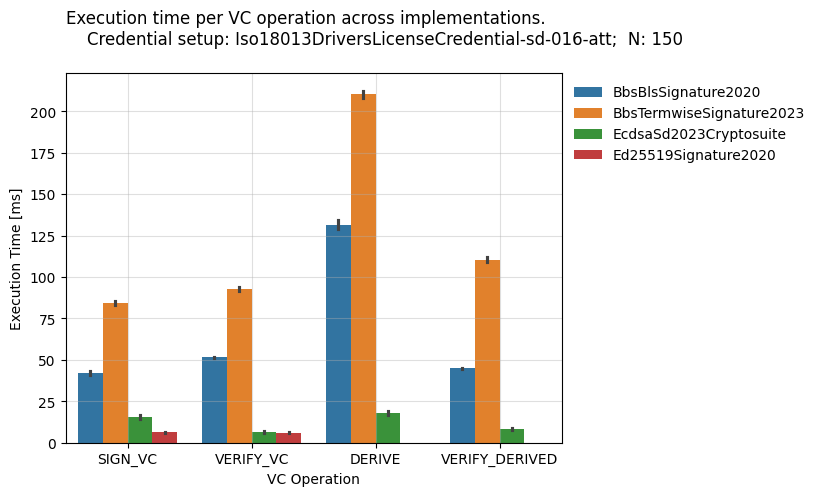

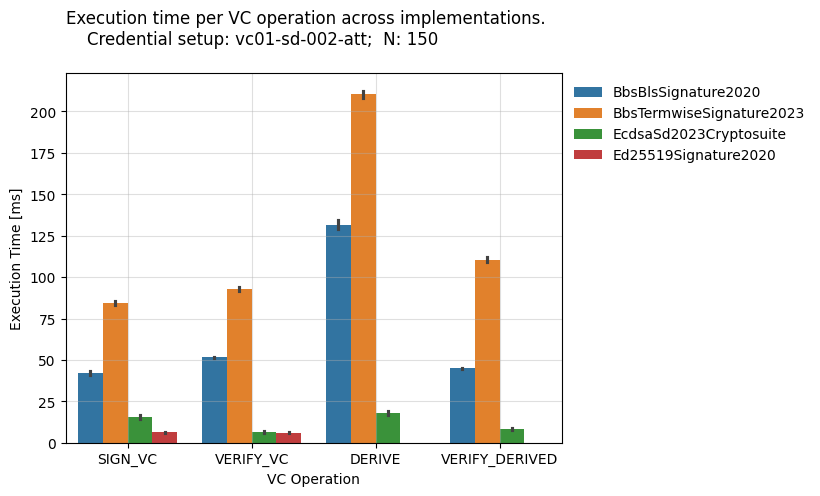

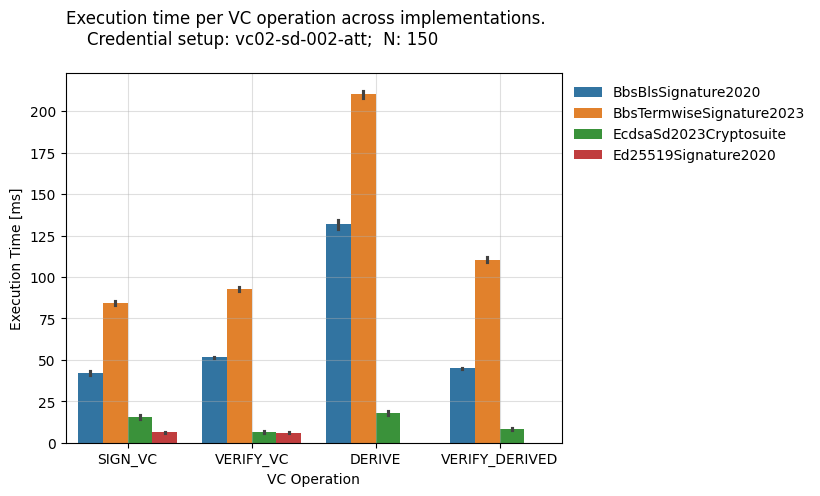

In [59]:
for csk in csk_vc.index:
    N = dfsb.iteration.max() + 1
    
    ax = sns.barplot(
        data = dfsb,
        x = 'step',
        y = 'delta',
        hue = 'implementation',
        order=step_order,
        hue_order=implementation_order
    )
    
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time per VC operation across implementations.
    Credential setup: {csk};  N: {N}
    ''',loc='left')
    ax.set_xlabel('VC Operation')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    plt.show()
    
    

Let's focus on each VC operation separately.

In [60]:
STEPS = ['SIGN_VC', 'VERIFY_VC','DERIVE', 'VERIFY_DERIVED']

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


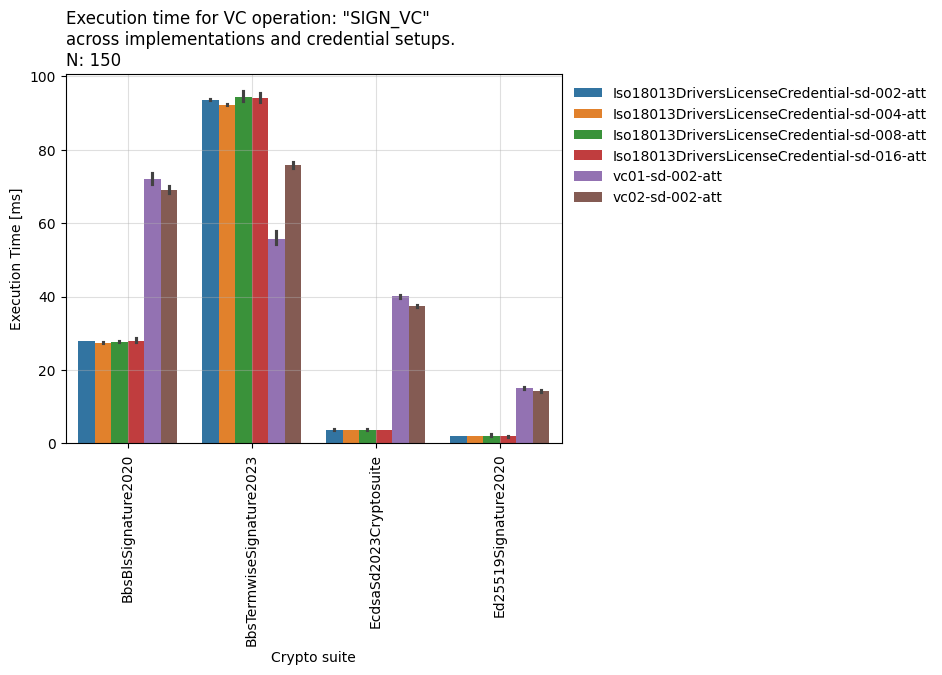

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


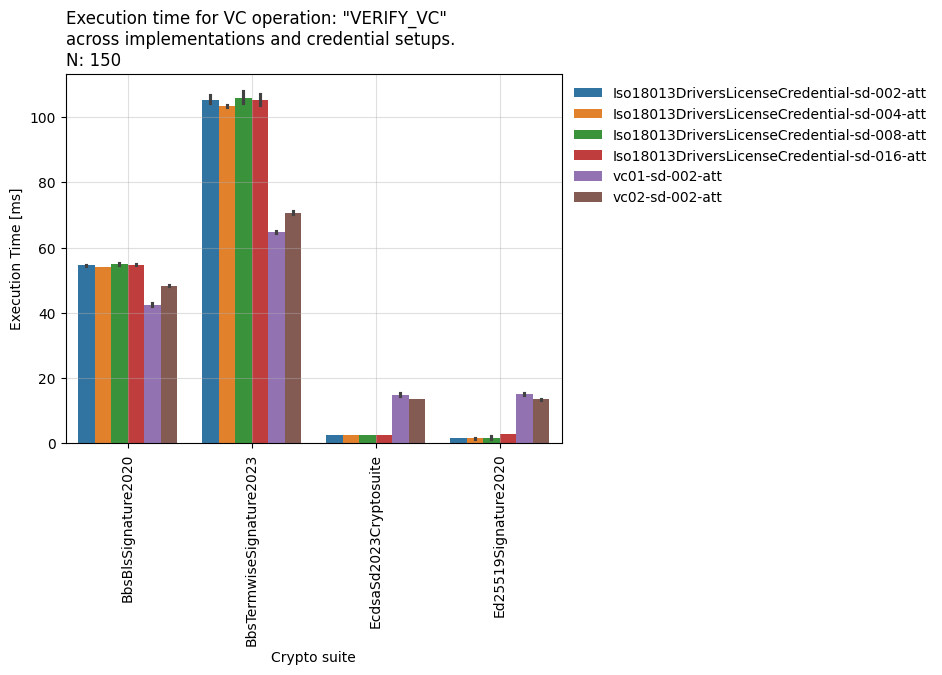

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


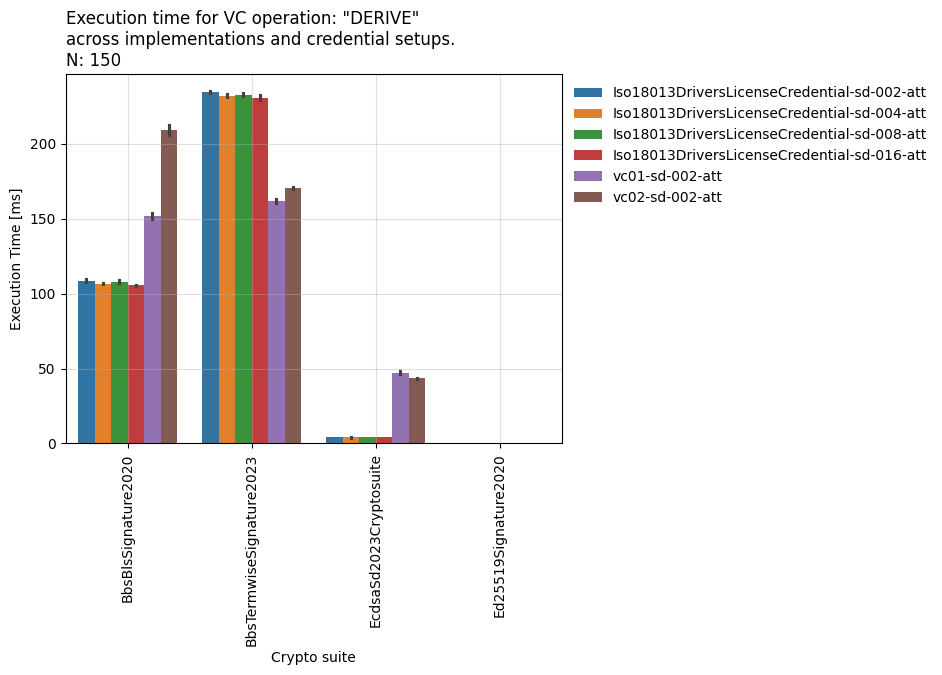

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/4144021870.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


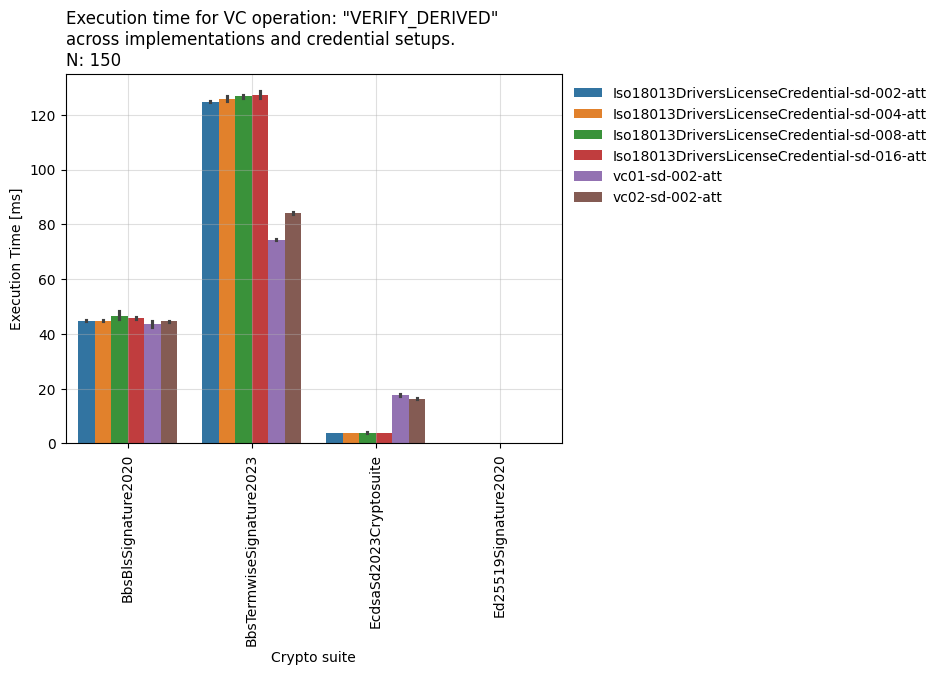

In [61]:
for step_i in STEPS:
    dfsb_step_i = dfsb[dfsb.step == step_i]
    ax = sns.barplot(
            data = dfsb_step_i,
            x = 'implementation',
            y = 'delta',
            hue = 'credentialSetupKey',
            order=implementation_order
        )
    ax.legend(frameon=False, bbox_to_anchor=(1,1))
    ax.set_title(f'''Execution time for VC operation: "{step_i}" \nacross implementations and credential setups.\nN: {N}''',loc='left')
    ax.set_xlabel('Crypto suite')
    ax.set_ylabel('Execution Time [ms]')
    ax.grid(alpha=.4)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    plt.show()

---

## Single credential focus

In [62]:
cred = 'vc01'
assert cred in evaluated_credentials
print(f'Credential: {cred}')

Credential: vc01


In [64]:
dfsb_cred = dfsb[dfsb.credential == cred]
assert dfsb_cred.credential.unique().__len__() == 1 # Make sure we're dealing with exactly one credential
dfsb_cred.shape

(2100, 7)

In [72]:
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    g = sns.FacetGrid(dfsb_cred, col='step', col_order=STEPS, sharey=True)
    g.map_dataframe(sns.lineplot,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',)
    
    g.axes.ravel()[0].legend(frameon=False, bbox_to_anchor=(6,1))
    #for ax in g.axes.ravel():
    #    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    
    #ax.legend(frameon=False, bbox_to_anchor=(2,1))
    plt.suptitle(f'(DRAFT VERSION) Credential: {cred} -  Absolute values',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

Warning: This plot considers a range of values for n_sd_att, which is not the case for credential: vc01

In [75]:
step_i = 'DERIVE'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=False
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

Warning: This plot considers a range of values for n_sd_att, which is not the case for credential: vc01

In [76]:
step_i = 'VERIFY_DERIVED'
# This plot considers a range of values for n_sd_att
if dfsb_cred.n_sd_att.unique().__len__() > 1:
    dfsb_step_i = dfsb_cred[dfsb.step == step_i]
    g = sns.catplot(
        data = dfsb_step_i,
        x = 'n_sd_att',
        y = 'delta',
        col = 'implementation',
        kind = 'point',
        aspect=1,
        sharey=False
    )
    plt.suptitle(f'Step: {step_i}\nCredential: {cred}',y=1.1)
else:
    raise Warning(f'This plot considers a range of values for n_sd_att, which is not the case for credential: {cred}')

Warning: This plot considers a range of values for n_sd_att, which is not the case for credential: vc01

---

In [79]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
#I.reset_index().credentialSetupKey.str.split('-sd-').apply(lambda x: x[0])
I['credentialSetupKey'] = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values

In [80]:
# The mean execution times for SIGN_VC & VERIFY_VC can be aggregated because the number of disclosed attributes does not influence their execution time
I = df_mean.stack().loc[['SIGN_VC','VERIFY_VC']]
# To do this, we create the same credentialSetupKey for every -sd-\d{3} variant
new_credentialSetupKey_values = pd.Series(I.index.get_level_values('credentialSetupKey')).str.split('-sd-').apply(lambda x: x[0]).values
I.reset_index(inplace=True)
I['credentialSetupKey'] = new_credentialSetupKey_values
display(I)

# Let's aggregate
I_agg = I.reset_index().groupby(['step', 'credentialSetupKey']).mean().drop('index',axis=1)
print('I_agg')
display(I_agg)

# Execution times for DERIVE and VERIFY_DERIVED must be kept as-is (i.e., separated per nr of disclosed attributes)
J = df_mean.stack().loc[['DERIVE','VERIFY_DERIVED']]
print('J')
display(J)

implementation,step,credentialSetupKey,BbsBlsSignature2020,BbsTermwiseSignature2023,EcdsaSd2023Cryptosuite,Ed25519Signature2020
0,SIGN_VC,Iso18013DriversLicenseCredential,27.88,93.66,3.79,2.01
1,SIGN_VC,Iso18013DriversLicenseCredential,27.51,92.35,3.66,1.98
2,SIGN_VC,Iso18013DriversLicenseCredential,27.72,94.38,3.75,2.15
3,SIGN_VC,Iso18013DriversLicenseCredential,27.99,94.03,3.63,1.91
4,SIGN_VC,vc01,72.10,55.64,40.10,15.16
5,SIGN_VC,vc02,69.04,75.84,37.45,14.28
6,VERIFY_VC,Iso18013DriversLicenseCredential,54.61,105.41,2.56,1.58
7,VERIFY_VC,Iso18013DriversLicenseCredential,54.03,103.35,2.47,1.53
8,VERIFY_VC,Iso18013DriversLicenseCredential,54.98,105.87,2.53,1.72
9,VERIFY_VC,Iso18013DriversLicenseCredential,54.83,105.20,2.50,2.93


I_agg


implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.7750   
          vc01                                          72.1000   
          vc02                                          69.0400   
VERIFY_VC Iso18013DriversLicenseCredential              54.6125   
          vc01                                          42.4300   
          vc02                                          48.3900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                   93.6050   
          vc01                                               55.6400   
          vc02                                               75.8400   
VERIFY_VC Iso18013DriversLicenseCredential                  104.9575   
          vc01                                               64.7800   
          vc02                                               70.7700   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7075   
          vc01                                             40.1000   
          vc02                                             37.4500   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5150   
          vc01                                             14.8900   
          vc02                                             13.5800   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                2.0125  
          vc01                                           15.1600  
          vc02                                           14.2800  
VERIFY_VC Iso18013DriversLicenseCredential                1.9400  
          vc01                                           15.0900  
          vc02                                           13.5300

J


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att               108.62   
               Iso18013DriversLicenseCredential-sd-004-att               106.74   
               Iso18013DriversLicenseCredential-sd-008-att               107.78   
               Iso18013DriversLicenseCredential-sd-016-att               105.66   
               vc01-sd-002-att                                           151.78   
               vc02-sd-002-att                                           209.35   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                44.80   
               Iso18013DriversLicenseCredential-sd-004-att                44.76   
               Iso18013DriversLicenseCredential-sd-008-att                46.51   
               Iso18013DriversLicenseCredential-sd-016-att                45.82   
               vc01-sd-002-att                                            43.54   
               vc02-sd-002-att                                            44.56   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    234.37   
               Iso18013DriversLicenseCredential-sd-004-att                    231.93   
               Iso18013DriversLicenseCredential-sd-008-att                    232.82   
               Iso18013DriversLicenseCredential-sd-016-att                    230.67   
               vc01-sd-002-att                                                161.60   
               vc02-sd-002-att                                                170.40   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    124.84   
               Iso18013DriversLicenseCredential-sd-004-att                    125.84   
               Iso18013DriversLicenseCredential-sd-008-att                    126.69   
               Iso18013DriversLicenseCredential-sd-016-att                    127.06   
               vc01-sd-002-att                                                 74.40   
               vc02-sd-002-att                                                 83.98   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                    4.16   
               Iso18013DriversLicenseCredential-sd-004-att                    3.99   
               Iso18013DriversLicenseCredential-sd-008-att                    4.09   
               Iso18013DriversLicenseCredential-sd-016-att                    4.06   
               vc01-sd-002-att                                               47.25   
               vc02-sd-002-att                                               43.54   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                    3.92   
               Iso18013DriversLicenseCredential-sd-004-att                    3.82   
               Iso18013DriversLicenseCredential-sd-008-att                    3.97   
               Iso18013DriversLicenseCredential-sd-016-att                    3.95   
               vc01-sd-002-att                                               17.55   
               vc02-sd-002-att                                               16.36   

implementation                                              Ed25519Signature2020  
step           credentialSetupKey                                                 
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                   NaN  
               Iso18013DriversLicenseCredential-sd-004-att                   NaN  
               Iso18013DriversLicenseCredential-sd-008-att         

In [81]:
I_agg

implementation                              BbsBlsSignature2020  \
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential              27.7750   
          vc01                                          72.1000   
          vc02                                          69.0400   
VERIFY_VC Iso18013DriversLicenseCredential              54.6125   
          vc01                                          42.4300   
          vc02                                          48.3900   

implementation                              BbsTermwiseSignature2023  \
step      credentialSetupKey                                           
SIGN_VC   Iso18013DriversLicenseCredential                   93.6050   
          vc01                                               55.6400   
          vc02                                               75.8400   
VERIFY_VC Iso18013DriversLicenseCredential                  104.9575   
          vc01                                               64.7800   
          vc02                                               70.7700   

implementation                              EcdsaSd2023Cryptosuite  \
step      credentialSetupKey                                         
SIGN_VC   Iso18013DriversLicenseCredential                  3.7075   
          vc01                                             40.1000   
          vc02                                             37.4500   
VERIFY_VC Iso18013DriversLicenseCredential                  2.5150   
          vc01                                             14.8900   
          vc02                                             13.5800   

implementation                              Ed25519Signature2020  
step      credentialSetupKey                                      
SIGN_VC   Iso18013DriversLicenseCredential                2.0125  
          vc01                                           15.1600  
          vc02                                           14.2800  
VERIFY_VC Iso18013DriversLicenseCredential                1.9400  
          vc01                                           15.0900  
          vc02                                           13.5300

In [82]:
# The concatenated result: K = I_agg & J
K = pd.concat([I_agg, J], axis=0)
K

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.7750   
               vc01                                                     72.1000   
               vc02                                                     69.0400   
VERIFY_VC      Iso18013DriversLicenseCredential                         54.6125   
               vc01                                                     42.4300   
               vc02                                                     48.3900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             108.6200   
               Iso18013DriversLicenseCredential-sd-004-att             106.7400   
               Iso18013DriversLicenseCredential-sd-008-att             107.7800   
               Iso18013DriversLicenseCredential-sd-016-att             105.6600   
               vc01-sd-002-att                                         151.7800   
               vc02-sd-002-att                                         209.3500   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              44.8000   
               Iso18013DriversLicenseCredential-sd-004-att              44.7600   
               Iso18013DriversLicenseCredential-sd-008-att              46.5100   
               Iso18013DriversLicenseCredential-sd-016-att              45.8200   
               vc01-sd-002-att                                          43.5400   
               vc02-sd-002-att                                          44.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                              93.6050   
               vc01                                                          55.6400   
               vc02                                                          75.8400   
VERIFY_VC      Iso18013DriversLicenseCredential                             104.9575   
               vc01                                                          64.7800   
               vc02                                                          70.7700   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                  234.3700   
               Iso18013DriversLicenseCredential-sd-004-att                  231.9300   
               Iso18013DriversLicenseCredential-sd-008-att                  232.8200   
               Iso18013DriversLicenseCredential-sd-016-att                  230.6700   
               vc01-sd-002-att                                              161.6000   
               vc02-sd-002-att                                              170.4000   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                  124.8400   
               Iso18013DriversLicenseCredential-sd-004-att                  125.8400   
               Iso18013DriversLicenseCredential-sd-008-att                  126.6900   
               Iso18013DriversLicenseCredential-sd-016-att                  127.0600   
               vc01-sd-002-att                                               74.4000   
               vc02-sd-002-att                                               83.9800   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7075   
               vc01                                                        40.1000   
               vc02                                                        37.4500   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5150   
               vc01                                           

---

Performance results overview

In [90]:
df_mean_stacked = K.copy()
print('df_mean_stacked.shape: ', df_mean_stacked.shape)
display(df_mean_stacked)
df_mean_stacked.round(2).to_clipboard()
print('df_mean_stacked was copied to clipboard!')

df_mean_stacked.shape:  (18, 4)


implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                         27.7750   
               vc01                                                     72.1000   
               vc02                                                     69.0400   
VERIFY_VC      Iso18013DriversLicenseCredential                         54.6125   
               vc01                                                     42.4300   
               vc02                                                     48.3900   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att             108.6200   
               Iso18013DriversLicenseCredential-sd-004-att             106.7400   
               Iso18013DriversLicenseCredential-sd-008-att             107.7800   
               Iso18013DriversLicenseCredential-sd-016-att             105.6600   
               vc01-sd-002-att                                         151.7800   
               vc02-sd-002-att                                         209.3500   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att              44.8000   
               Iso18013DriversLicenseCredential-sd-004-att              44.7600   
               Iso18013DriversLicenseCredential-sd-008-att              46.5100   
               Iso18013DriversLicenseCredential-sd-016-att              45.8200   
               vc01-sd-002-att                                          43.5400   
               vc02-sd-002-att                                          44.5600   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                              93.6050   
               vc01                                                          55.6400   
               vc02                                                          75.8400   
VERIFY_VC      Iso18013DriversLicenseCredential                             104.9575   
               vc01                                                          64.7800   
               vc02                                                          70.7700   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                  234.3700   
               Iso18013DriversLicenseCredential-sd-004-att                  231.9300   
               Iso18013DriversLicenseCredential-sd-008-att                  232.8200   
               Iso18013DriversLicenseCredential-sd-016-att                  230.6700   
               vc01-sd-002-att                                              161.6000   
               vc02-sd-002-att                                              170.4000   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                  124.8400   
               Iso18013DriversLicenseCredential-sd-004-att                  125.8400   
               Iso18013DriversLicenseCredential-sd-008-att                  126.6900   
               Iso18013DriversLicenseCredential-sd-016-att                  127.0600   
               vc01-sd-002-att                                               74.4000   
               vc02-sd-002-att                                               83.9800   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                             3.7075   
               vc01                                                        40.1000   
               vc02                                                        37.4500   
VERIFY_VC      Iso18013DriversLicenseCredential                             2.5150   
               vc01                                           

df_mean_stacked was copied to clipboard!


Relative performance results.

In [92]:
# relative to col
rel2c = 'EcdsaSd2023Cryptosuite'

In [93]:
# Compute relative performance
A = df_mean_stacked.values
B = df_mean_stacked[rel2c].values
C = (A.T / B).T
# df_C contains the performance values
df_C = pd.DataFrame(
    data=C,
    index=df_mean_stacked.index,
    columns=df_mean_stacked.columns
)
display(df_C.round(2))
df_C.round(2).to_clipboard()

implementation                                              BbsBlsSignature2020  \
step           credentialSetupKey                                                 
SIGN_VC        Iso18013DriversLicenseCredential                            7.49   
               vc01                                                        1.80   
               vc02                                                        1.84   
VERIFY_VC      Iso18013DriversLicenseCredential                           21.71   
               vc01                                                        2.85   
               vc02                                                        3.56   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                26.11   
               Iso18013DriversLicenseCredential-sd-004-att                26.75   
               Iso18013DriversLicenseCredential-sd-008-att                26.35   
               Iso18013DriversLicenseCredential-sd-016-att                26.02   
               vc01-sd-002-att                                             3.21   
               vc02-sd-002-att                                             4.81   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                11.43   
               Iso18013DriversLicenseCredential-sd-004-att                11.72   
               Iso18013DriversLicenseCredential-sd-008-att                11.72   
               Iso18013DriversLicenseCredential-sd-016-att                11.60   
               vc01-sd-002-att                                             2.48   
               vc02-sd-002-att                                             2.72   

implementation                                              BbsTermwiseSignature2023  \
step           credentialSetupKey                                                      
SIGN_VC        Iso18013DriversLicenseCredential                                25.25   
               vc01                                                             1.39   
               vc02                                                             2.03   
VERIFY_VC      Iso18013DriversLicenseCredential                                41.73   
               vc01                                                             4.35   
               vc02                                                             5.21   
DERIVE         Iso18013DriversLicenseCredential-sd-002-att                     56.34   
               Iso18013DriversLicenseCredential-sd-004-att                     58.13   
               Iso18013DriversLicenseCredential-sd-008-att                     56.92   
               Iso18013DriversLicenseCredential-sd-016-att                     56.82   
               vc01-sd-002-att                                                  3.42   
               vc02-sd-002-att                                                  3.91   
VERIFY_DERIVED Iso18013DriversLicenseCredential-sd-002-att                     31.85   
               Iso18013DriversLicenseCredential-sd-004-att                     32.94   
               Iso18013DriversLicenseCredential-sd-008-att                     31.91   
               Iso18013DriversLicenseCredential-sd-016-att                     32.17   
               vc01-sd-002-att                                                  4.24   
               vc02-sd-002-att                                                  5.13   

implementation                                              EcdsaSd2023Cryptosuite  \
step           credentialSetupKey                                                    
SIGN_VC        Iso18013DriversLicenseCredential                                1.0   
               vc01                                                            1.0   
               vc02                                                            1.0   
VERIFY_VC      Iso18013DriversLicenseCredential                                1.0   
               vc01                                           

In [86]:
df_C.to_clipboard()

---

/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/2095533028.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  dfsb_rel = df_C.drop(['SIGN_VC','VERIFY_VC'],axis=0).stack().rename('rel-delta').reset_index()
/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_20029/2095533028.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


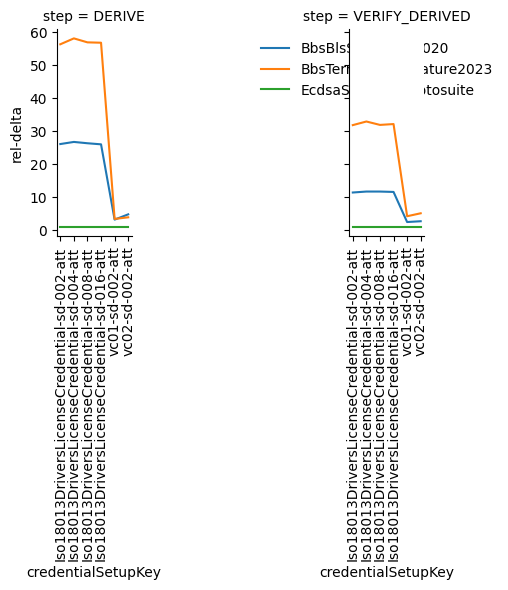

In [87]:
dfsb_rel = df_C.drop(['SIGN_VC','VERIFY_VC'],axis=0).stack().rename('rel-delta').reset_index()
g = sns.FacetGrid(dfsb_rel, col='step', row_order=STEPS, sharey=True, )
g.map_dataframe(sns.lineplot,
    x = 'credentialSetupKey',
    y = 'rel-delta',
    hue = 'implementation')

g.axes.ravel()[0].legend(frameon=False, bbox_to_anchor=(6,1))
for ax in g.axes.ravel():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

---
---
---